In [1]:
from pathlib import Path
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from pathlib import Path
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

documents = {}

for file in DATA_DIR.glob("*.txt"):
    documents[file.stem] = file.read_text(encoding="utf-8")

print(f"Loaded {len(documents)} documents.")

Loaded 108 documents.


In [2]:
def clean_text(text):
    """
    Clean and normalise input text for downstream processing.
    This function applies several preprocessing steps to standardise textual data:
    - Converts all characters to lowercase.
    - Removes page number markers (e.g., "p. 31").
    - Eliminates non-alphabetic characters and standalone punctuation.
    - Corrects common OCR artefacts such as merged words (e.g., "ofthe" → "of the").
    - Collapses multiple whitespace characters into a single space.
    - Strips leading and trailing whitespace.

    Parameters
    ----------
    text : str
        The raw input text to be cleaned.

    Returns
    -------
    str
        The cleaned and normalised text.
    """
    text = text.lower()
    
    # Remove page number markers like "p. 31"
    text = re.sub(r'\bp\.\s*\d+\b', ' ', text)
    
    # Remove standalone punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Fix common OCR join artefacts (optional)
    text = text.replace("ofthe", "of the")
    
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

cleaned_docs = {k: clean_text(v) for k, v in documents.items()}

# Corpus Document Count and Categories
This section reports the number of documents in the corpus and examines their distribution over time across the following categories:
- Book reviews
- Journal articles
- Conference presentations
- Book chapters


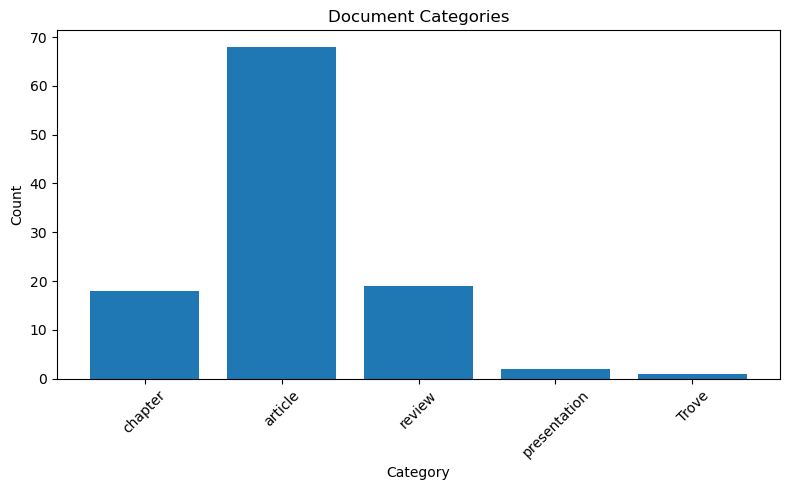

chapter: 18 documents
article: 68 documents
review: 19 documents
presentation: 2 documents
 Trove: 1 documents
Total: 108 documents


In [3]:
# Plot categories of documents using last section of filename categories as either "journal-article", "book-chapter", or "book-review"
categories = [name.split("-")[-1] for name in cleaned_docs.keys()]
category_counts = Counter(categories)
plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values())
plt.title("Document Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#print number of items in each category with a 'total' number of documents at the end
total_documents = sum(category_counts.values())
for category, count in category_counts.items():
    print(f"{category}: {count} documents")
print(f"Total: {total_documents} documents") 

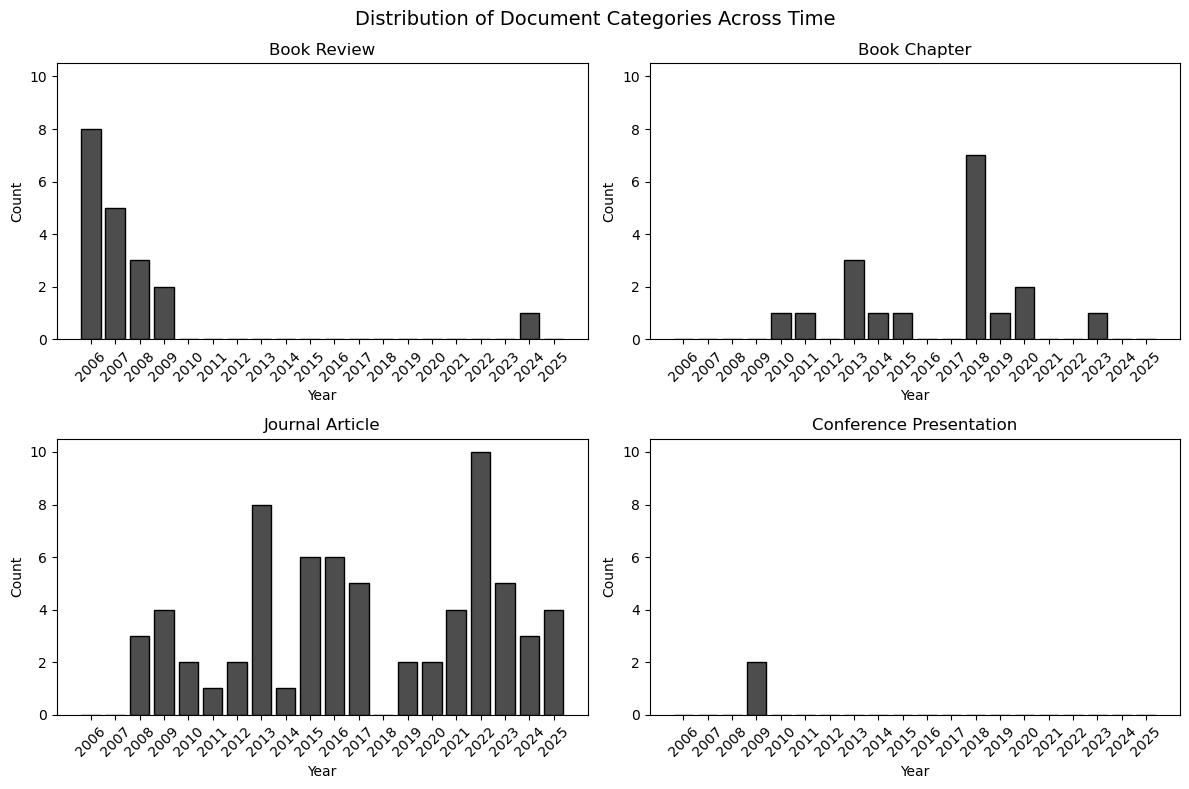

In [4]:
# Visualise document counts over time using a 2×2 grid of bar charts
# for book reviews, book chapters, journal articles, and conference presentations.

from collections import Counter
import re
import matplotlib.pyplot as plt
import os

# Count documents by year and category
year_category_counts = {}

for name in cleaned_docs.keys():
    match = re.search(r'(\d{4})', name)
    if match:
        year = match.group(1)
        category = os.path.splitext(name.split("__")[-1])[0]

        if year not in year_category_counts:
            year_category_counts[year] = Counter()

        year_category_counts[year][category] += 1

# Sort years (ensure numerical order)
years = sorted(year_category_counts.keys(), key=int)

# Categories to plot
categories_to_plot = [
    "book-review",
    "book-chapter",
    "journal-article",
    "conference-presentation"
]

# Create a 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

# Add overall title for all subplots
fig.suptitle("Distribution of Document Categories Across Time", fontsize=14)

for ax, category in zip(axes, categories_to_plot):
    counts = [year_category_counts[year][category] for year in years]

    ax.bar(years, counts, color="#4d4d4d", edgecolor="black")

    ax.set_title(category.replace('-', ' ').title())
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")

    # Ensure ticks are visible on all subplots
    ax.tick_params(axis='x', rotation=45, labelbottom=True)
    ax.tick_params(labelleft=True)

plt.tight_layout()
plt.show()

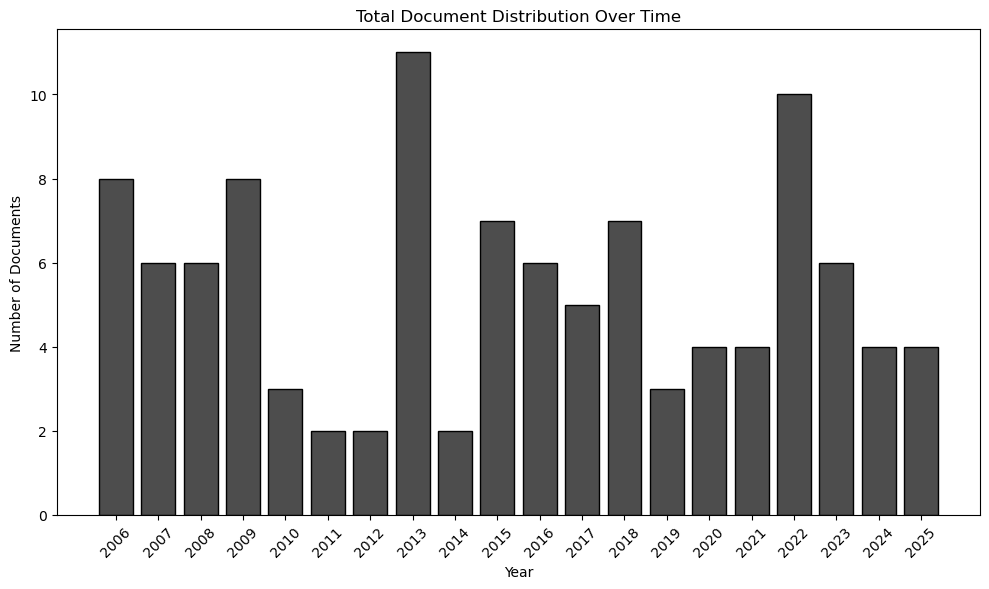

In [5]:
# Aggregate total document counts per year (across all categories)
total_counts = {
    year: sum(year_category_counts[year].values())
    for year in years
}

# Prepare data for plotting
total_values = [total_counts[year] for year in years]

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(years, total_values, color="#4d4d4d", edgecolor="black")

plt.title("Total Document Distribution Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Word Frequency Analysis

In [6]:
"""
Identify most common content words in the corpus
(after removing stopwords and domain-specific noise (words introduced convertin PDF to text documents)
"""

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

# ----------------------------
# 1. Remove standard stopwords
# ----------------------------
all_words = " ".join(cleaned_docs.values()).split()
freq = Counter(all_words)

filtered_words = [
    w for w in all_words
    if w not in ENGLISH_STOP_WORDS
]

# ----------------------------
# 2. Define domain-specific exclusions
# ----------------------------
remove_terms = {
    'carpentaria', 'wright', 'alexis', 's'
}

noise_terms = {
    'functionality', 'licensors', 'warranties', 'cengage',
    'gale', 'machine', 'generated', 'pdf',
    'copyright', 'reproduced', 'permission',
    'vol', 'issue', 'page', 'pp', 'p',
    'feb', 'february',
    'informit', 'timrofni', 'ylrehtuos',
    'eht', 'fo', 'like'
}

# NOTE: you removed 'indigenous' and 'aboriginal' earlier
# consider whether you actually want to exclude these,
# as they may be analytically important

exclusion_terms = remove_terms.union(noise_terms)

# ----------------------------
# 3. Final filtering
# ----------------------------
filtered_words = [
    w for w in filtered_words
    if len(w) > 2 and w not in exclusion_terms
]

# ----------------------------
# 4. Count frequencies
# ----------------------------
word_counts = Counter(filtered_words)

top_words = word_counts.most_common(20)

# Display
for word, count in top_words:
    print(f"{word}: {count}")

indigenous: 3343
aboriginal: 2589
australian: 2159
novel: 1841
people: 1702
australia: 1341
literature: 1301
world: 1178
land: 1169
white: 1130
new: 1099
time: 1049
country: 1044
story: 1006
literary: 954
narrative: 937
writing: 931
history: 924
place: 830
cultural: 800


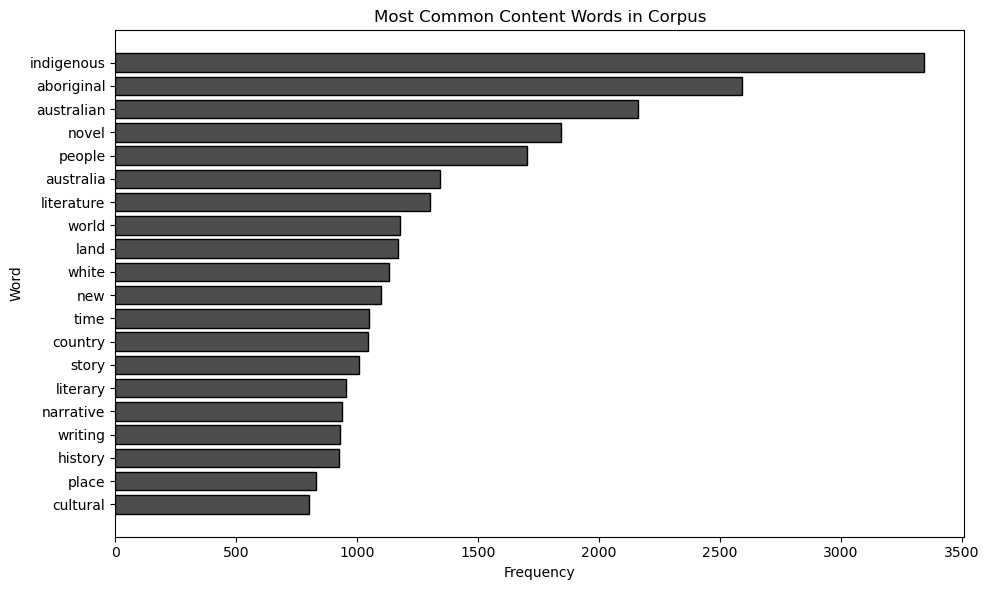

In [7]:
import matplotlib.pyplot as plt

if top_words:
    words = [word for word, count in top_words]
    counts = [count for word, count in top_words]

    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], counts[::-1], color="#4d4d4d", edgecolor="black")

    plt.title("Most Common Content Words in Corpus")
    plt.xlabel("Frequency")
    plt.ylabel("Word")

    plt.tight_layout()
    plt.show()
else:
    print("No words available to plot.")

Based on an analysis of the most frequent terms, key words were grouped into thematic categories to support further analysis, including Indigenous, Aboriginal, land, country, history, time, white, and whiteness.


Using terms: ['indigenous', 'aboriginal', 'land', 'country', 'history', 'time', 'white', 'whiteness']


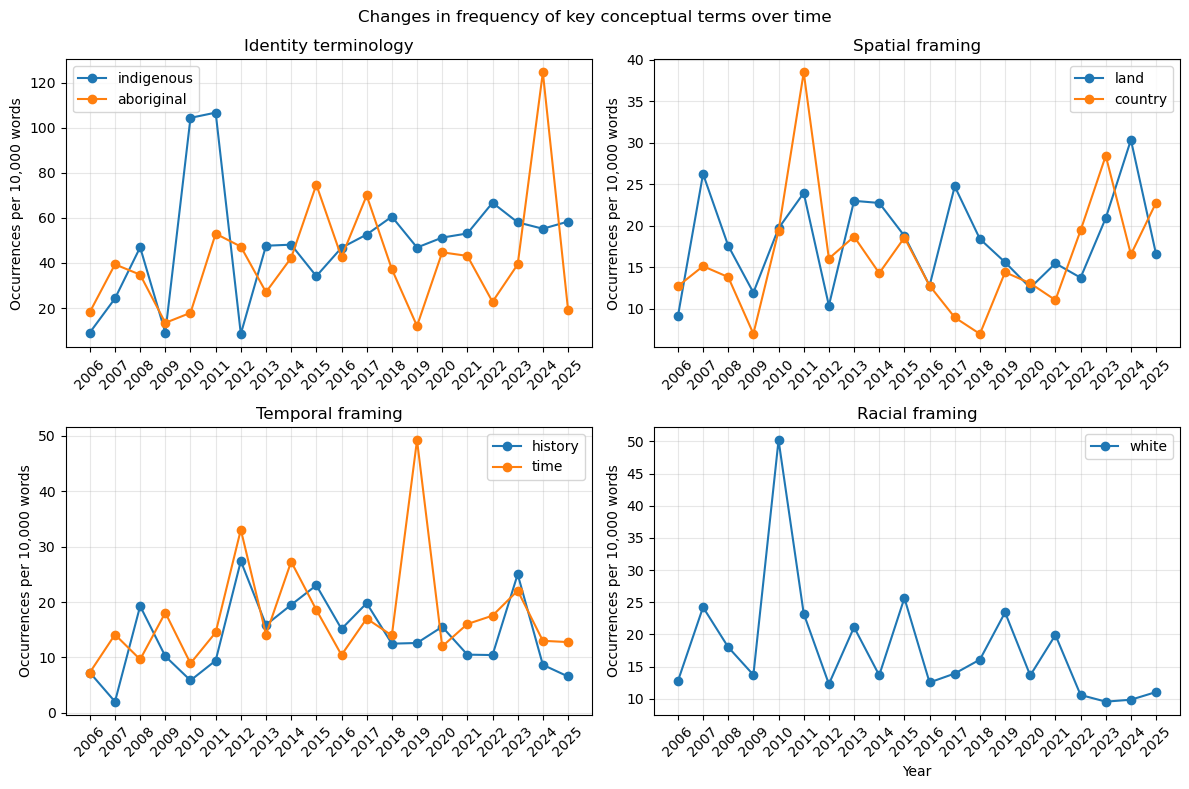

In [8]:
"""
Unigram temporal analysis
(normalised per 10,000 words)
"""

import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# ----------------------------
# 1. Prepare dataframe
# ----------------------------
def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

doc_names = list(cleaned_docs.keys())
texts = list(cleaned_docs.values())

df = pd.DataFrame({
    "filename": doc_names,
    "text": texts
})

df["year"] = df["filename"].apply(extract_year)
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

# ----------------------------
# 2. Word counts
# ----------------------------
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

# ----------------------------
# 3. Unigram matrix
# ----------------------------
vectorizer = CountVectorizer(ngram_range=(1,1), stop_words="english")
X = vectorizer.fit_transform(df["text"])

unigram_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

unigram_df["year"] = df["year"].values
unigram_df["word_count"] = df["word_count"].values

# ----------------------------
# 4. Select terms
# ----------------------------
target_terms = [
    "indigenous",
    "aboriginal",
    "land",
    "country",
    "history",
    "time",
    "white",
    "whiteness"

    
]

available_terms = [t for t in target_terms if t in unigram_df.columns]

print("Using terms:", available_terms)

# ----------------------------
# 5. Aggregate by year
# ----------------------------
yearly = (
    unigram_df.groupby("year")[available_terms + ["word_count"]]
    .sum()
    .rename(columns={"word_count": "total_words"})
    .sort_index()
)

# ----------------------------
# 6. Normalise per 10,000 words
# ----------------------------
for term in available_terms:
    yearly[f"{term}_per_10k"] = (
        yearly[term] / yearly["total_words"]
    ) * 10000

# ----------------------------
# 7. Plot grouped comparisons (with analytical titles)
# ----------------------------
plot_groups = [
    (["indigenous", "aboriginal"], "Identity terminology"),
    (["land", "country"], "Spatial framing"),
    (["history", "time"], "Temporal framing"),
    (["white"], "Racial framing")
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

years = yearly.index.astype(int)

for ax, (group, title) in zip(axes, plot_groups):
    for term in group:
        if term in available_terms:
            ax.plot(
                years,
                yearly[f"{term}_per_10k"],
                marker="o",
                label=term
            )

    ax.set_title(title)
    ax.set_ylabel("Occurrences per 10,000 words")
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45, labelbottom=True)
    ax.grid(True, alpha=0.3)

# Only show legend if multiple terms
    if len(group) > 0:
        ax.legend() 

plt.xlabel("Year")
plt.suptitle("Changes in frequency of key conceptual terms over time")
plt.tight_layout()
plt.show()

# Bigram Analysis

In [9]:

# Combine all documents into one corpus list
corpus = list(cleaned_docs.values())

# Combine standard stopwords with your exclusions
combined_stopwords = set(ENGLISH_STOP_WORDS).union(exclusion_terms)

vectorizer = CountVectorizer(
    stop_words=list(combined_stopwords),
    ngram_range=(2, 2),
    token_pattern=r"(?u)\b[a-z]{3,}\b",
    min_df=2
)

X = vectorizer.fit_transform(corpus)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

bigram_freq = pd.DataFrame({
    "bigram": bigrams,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

bigram_freq.head(50)

,bigram,count
2198,australian literature,422
182,aboriginal people,313
17826,magical realism,282
29806,swan book,238
20228,new york,213
14264,indigenous people,199
4767,climate change,179
31822,university press,166
29478,study australian,158
1744,association study,154


# TF-IDF Corpus Analysis
Aggregating documents by year allows for the identification of broad thematic trends, though it may amplify the influence of individual texts within a given year.

In [10]:
"""
TF-IDF analysis by year (with exclusion of noise and text-specific terms)
"""

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# ----------------------------
# 1. Prepare dataframe
# ----------------------------
def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

doc_names = list(cleaned_docs.keys())
texts = list(cleaned_docs.values())

df = pd.DataFrame({
    "filename": doc_names,
    "text": texts
})

df["year"] = df["filename"].apply(extract_year)
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

# ----------------------------
# 2. Combine all documents within each year
# ----------------------------
yearly_texts = (
    df.groupby("year")["text"]
    .apply(lambda texts: " ".join(texts))
    .sort_index()
)

# ----------------------------
# 3. Define exclusion terms
# ----------------------------
exclusion_terms = [
    # authors / texts
    "wright", "carpentaria", "alexis",
    
    # OCR / artefacts
    "yduts", "nailartsua", "erutaretil", "noitaicossa", "lanruoj"  "nailartsua", "eht", "fo", "morf", "enruoblem", "ytisrevinu", "abr", "abr", "reviews", "online", "australianbookreview", 
    "eu", "page", "archive", "october",  "component", "https", "net", "author", 
    "issue", "ns", "cy", "com", "print", "oceania", "current", "www", "au", "pg", "allauthors", "tag", "byalexiswright",
    
    # generic / low-value
    "people", "new", "like", "book", "review"
]

# ----------------------------
# 4. Compute TF-IDF
# ----------------------------
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english",
    min_df=2
)

X_tfidf = tfidf_vectorizer.fit_transform(yearly_texts.values)
terms = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    index=yearly_texts.index,
    columns=terms
)

# ----------------------------
# 5. Remove unwanted terms
# ----------------------------
tfidf_df = tfidf_df.drop(
    columns=[t for t in exclusion_terms if t in tfidf_df.columns],
    errors="ignore"
)

# ----------------------------
# 6. Extract top terms per year
# ----------------------------
top_n = 30  # expanded for better tracking

top_terms_by_year = {}

for year in tfidf_df.index:
    top_terms = (
        tfidf_df.loc[year]
        .sort_values(ascending=False)
        .head(top_n)
    )
    top_terms_by_year[year] = pd.DataFrame({
        "term": top_terms.index,
        "tfidf_score": top_terms.values
    })

# ----------------------------
# 7. Display results
# ----------------------------
for year, table in top_terms_by_year.items():
    print(f"\n=== {year} ===")
    display(table)


=== 2006 ===


,term,tfidf_score
0,mcfadyen,0.252358
1,kate,0.114487
2,novel,0.109459
3,australia,0.090423
4,shesays,0.084119
5,town,0.076146
6,yorta,0.069533
7,english,0.064887
8,norm,0.052350
9,phantom,0.052350



=== 2007 ===


,term,tfidf_score
0,aboriginal,0.176529
1,norm,0.172002
2,sea,0.158423
3,novel,0.135791
4,town,0.135791
5,man,0.131265
6,land,0.117686
7,desperance,0.113159
8,pool,0.110221
9,white,0.108633



=== 2008 ===


...

,term,tfidf_score
0,indigenous,0.276755
1,aboriginal,0.187759
2,nature,0.162797
3,western,0.143261
4,country,0.135664
5,ecological,0.130150
6,australian,0.126982
7,colonial,0.125363
8,world,0.121555
9,history,0.119384



=== 2024 ===


,term,tfidf_score
0,aboriginal,0.521014
1,indigenous,0.230829
2,australian,0.179717
3,literary,0.133551
4,roam,0.131143
5,land,0.126956
6,orality,0.125134
7,cultural,0.115415
8,als,0.100805
9,sutton,0.092286



=== 2025 ===


,term,tfidf_score
0,indigenous,0.262877
1,infrastructure,0.254620
2,listening,0.212912
3,infrastructures,0.178024
4,settler,0.143561
5,gothic,0.143132
6,reading,0.135405
7,novel,0.133772
8,pedagogy,0.128783
9,island,0.105773


Using focus terms: ['indigenous', 'aboriginal', 'sovereignty', 'law', 'settler', 'colonial', 'mining', 'climate_change', 'anthropocene', 'nature', 'island', 'space', 'magical_realism', 'postcolonial', 'listening', 'reading']


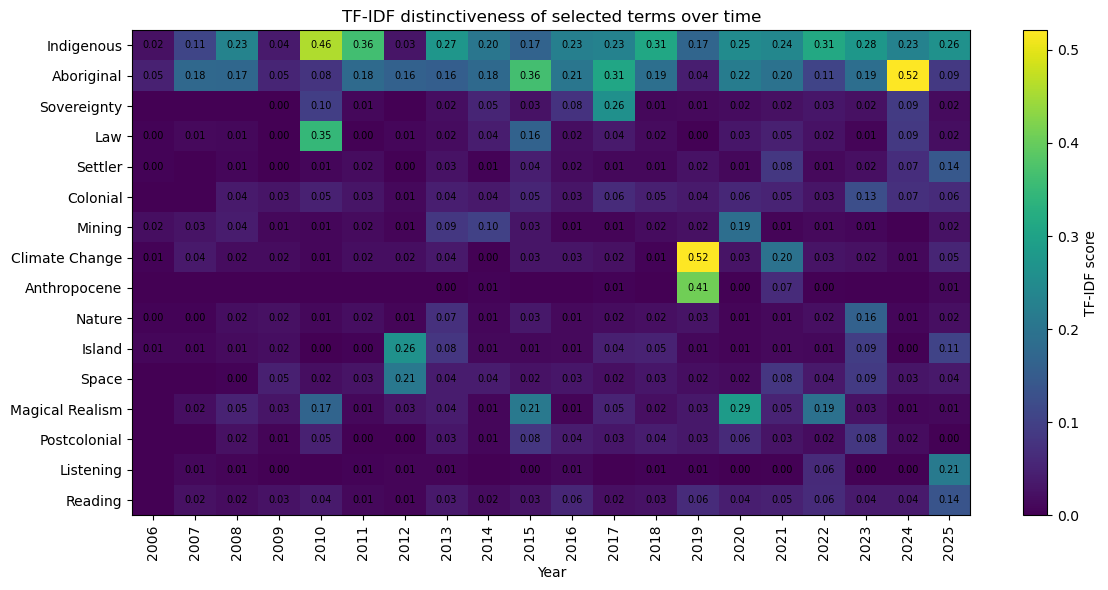

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1. Create combined terms
# ----------------------------
# Magical realism
tfidf_df["magical_realism"] = 0
if "magical" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["magical"]
if "realism" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["realism"]

# Climate change
tfidf_df["climate_change"] = 0
if "climate" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["climate"]
if "change" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["change"]

# ----------------------------
# 2. Define selected terms
# ----------------------------
selected_focus_terms = [
    "indigenous",
    "aboriginal",
    "sovereignty",
    "law",
    "settler",
    "colonial",
    "mining",
    "climate_change",
    "anthropocene",
    "nature",
    "island",
    "space",
    "magical_realism",
    "postcolonial",
    "listening",
    "reading",
]

# ----------------------------
# 3. Filter available terms
# ----------------------------
available_focus_terms = [t for t in selected_focus_terms if t in tfidf_df.columns]
print("Using focus terms:", available_focus_terms)

focus_tfidf = tfidf_df[available_focus_terms].copy()
years = focus_tfidf.index.astype(int)

# ----------------------------
# 4. Prepare heatmap data
# ----------------------------
heatmap_data = focus_tfidf.T.values  # terms as rows, years as columns

# Make labels more readable
display_labels = [
    term.replace("_", " ").title()
    for term in available_focus_terms
]

# ----------------------------
# 5. Plot heatmap
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

# Axis labels
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=90)
ax.set_yticks(np.arange(len(display_labels)))
ax.set_yticklabels(display_labels)

ax.set_xlabel("Year")
ax.set_title("TF-IDF distinctiveness of selected terms over time")

# Add colour bar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("TF-IDF score")

# Optional: annotate cells with values
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]
        if value > 0:
            ax.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

plt.tight_layout()
plt.show()

Using focus terms: ['sovereignty', 'settler', 'colonial', 'law', 'mining', 'climate_change', 'anthropocene', 'island', 'space', 'magical_realism', 'postcolonial', 'listening', 'reading', 'world', 'white_whiteness', 'country', 'land', 'place']


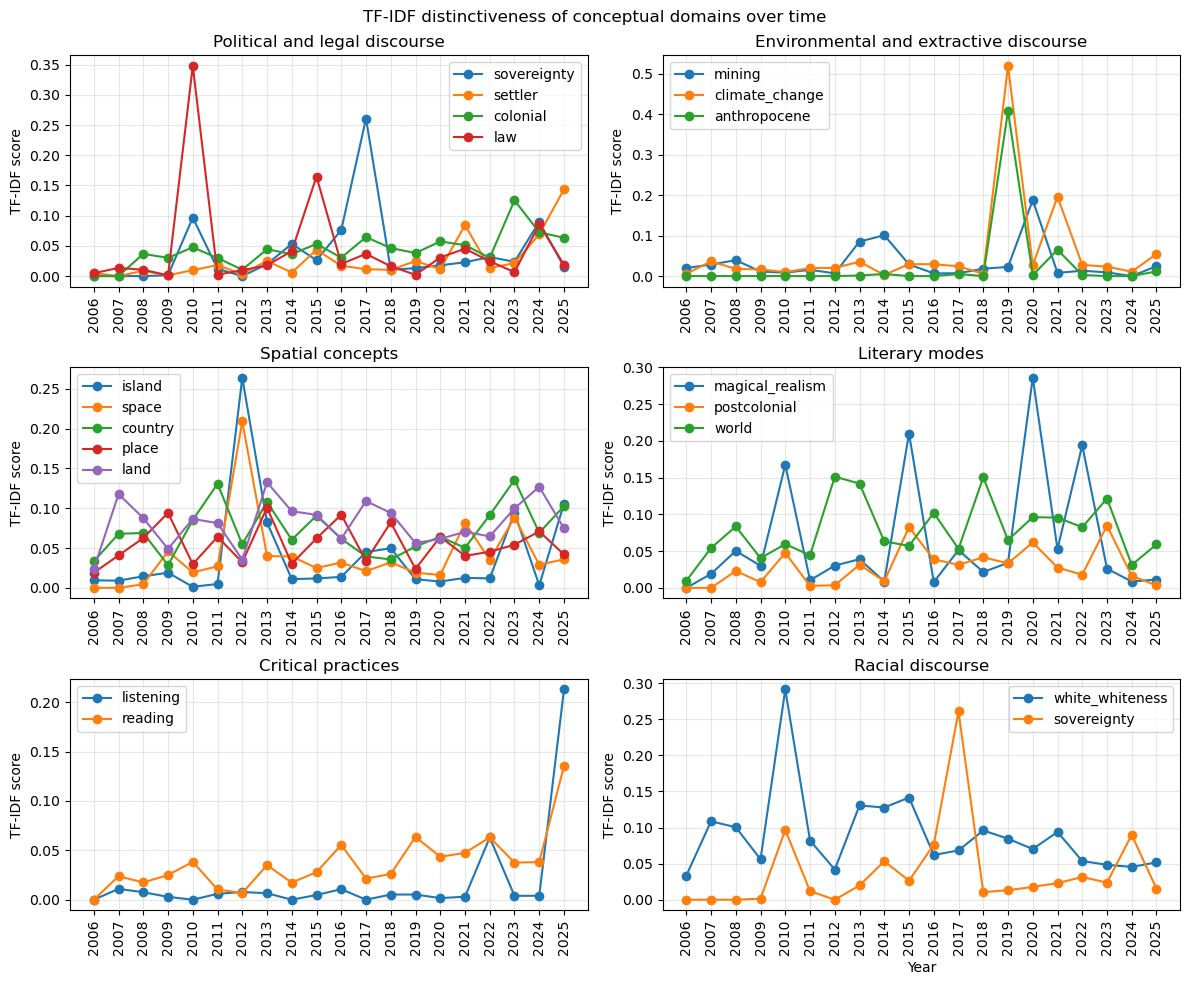

In [12]:
import matplotlib.pyplot as plt

# ----------------------------
# 1. Create combined terms
# ----------------------------
# Magical realism
tfidf_df["magical_realism"] = 0
if "magical" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["magical"]
if "realism" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["realism"]

# Climate change
tfidf_df["climate_change"] = 0
if "climate" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["climate"]
if "change" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["change"]

# White + whiteness
tfidf_df["white_whiteness"] = 0
if "white" in tfidf_df.columns:
    tfidf_df["white_whiteness"] += tfidf_df["white"]
if "whiteness" in tfidf_df.columns:
    tfidf_df["white_whiteness"] += tfidf_df["whiteness"]

# ----------------------------
# 2. Define selected terms
# ----------------------------
selected_focus_terms = [
    "sovereignty",
    "settler",
    "colonial",
    "law",
    "mining",
    "climate_change",
    "anthropocene",
    "island",
    "space",
    "magical_realism",
    "postcolonial",
    "listening",
    "reading",
    "world",
    "white_whiteness",
    "country",
    "land",
    "place"
]

# ----------------------------
# 3. Filter available terms
# ----------------------------
available_focus_terms = [t for t in selected_focus_terms if t in tfidf_df.columns]
print("Using focus terms:", available_focus_terms)

focus_tfidf = tfidf_df[available_focus_terms].copy()
years = focus_tfidf.index.astype(int)

# ----------------------------
# 4. Define conceptual groups
# ----------------------------
plot_groups = [
    (["sovereignty", "settler", "colonial", "law"], "Political and legal discourse"),
    (["mining", "climate_change", "anthropocene"], "Environmental and extractive discourse"),
    (["island", "space", "country", "place", "land"], "Spatial concepts"),
    (["magical_realism", "postcolonial", "world"], "Literary modes"),
    (["listening", "reading"], "Critical practices"),
    (["white_whiteness", "sovereignty"], "Racial discourse")
]

# ----------------------------
# 5. Plot
# ----------------------------
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), sharex=False)
axes = axes.flatten()

for ax, (group, title) in zip(axes, plot_groups):
    plotted = []

    for term in group:
        if term in focus_tfidf.columns:
            ax.plot(
                years,
                focus_tfidf[term],
                marker="o",
                label=term
            )
            plotted.append(term)

    ax.set_title(title)
    ax.set_ylabel("TF-IDF score")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=90)
    ax.grid(True, alpha=0.3)

    if len(plotted) > 1:
        ax.legend()

# Remove unused subplot (if any)
for j in range(len(plot_groups), len(axes)):
    fig.delaxes(axes[j])

plt.xlabel("Year")
plt.suptitle("TF-IDF distinctiveness of conceptual domains over time")
plt.tight_layout()
plt.show()

In [13]:
# ------------------------------------------------------------
# Top 5 articles for each selected TF-IDF category (PRINT ONLY)
# ------------------------------------------------------------

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# ----------------------------
# 1. Prepare document-level dataframe
# ----------------------------
doc_df = pd.DataFrame({
    "filename": list(cleaned_docs.keys()),
    "text": list(cleaned_docs.values())
})

def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

doc_df["year"] = doc_df["filename"].apply(extract_year)

# ----------------------------
# 2. Reuse exclusion terms if available
# ----------------------------
if "exclusion_terms" not in globals():
    exclusion_terms = []

# ----------------------------
# 3. Compute document-level TF-IDF
# ----------------------------
doc_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english",
    min_df=2
)

X_doc_tfidf = doc_tfidf_vectorizer.fit_transform(doc_df["text"])
doc_terms = doc_tfidf_vectorizer.get_feature_names_out()

doc_tfidf_df = pd.DataFrame(
    X_doc_tfidf.toarray(),
    index=doc_df["filename"],
    columns=doc_terms
)

# remove exclusion terms if present
doc_tfidf_df = doc_tfidf_df.drop(
    columns=[t for t in exclusion_terms if t in doc_tfidf_df.columns],
    errors="ignore"
)

# ----------------------------
# 4. Create combined conceptual categories
# ----------------------------
doc_focus_df = doc_tfidf_df.copy()

def combine_terms(df, new_col, terms):
    df[new_col] = 0
    for t in terms:
        if t in df.columns:
            df[new_col] += df[t]

combine_terms(doc_focus_df, "climate_change", ["climate", "change"])
combine_terms(doc_focus_df, "magical_realism", ["magical", "realism"])
combine_terms(doc_focus_df, "white_whiteness", ["white", "whiteness"])

# ----------------------------
# 5. Categories of interest
# ----------------------------
selected_focus_terms = [
    "sovereignty",
    "settler",
    "colonial",
    "law",
    "mining",
    "climate_change",
    "anthropocene",
    "island",
    "space",
    "magical_realism",
    "postcolonial",
    "listening",
    "reading",
    "world",
    "white_whiteness",
    "country",
    "land",
    "place"
]

available_focus_terms = [t for t in selected_focus_terms if t in doc_focus_df.columns]
missing_focus_terms = [t for t in selected_focus_terms if t not in doc_focus_df.columns]

print("Available terms:", available_focus_terms)
if missing_focus_terms:
    print("Missing terms:", missing_focus_terms)

# ----------------------------
# 6. Print top 5 per category
# ----------------------------
top_n = 5

for term in available_focus_terms:
    print(f"\n{'='*80}")
    print(f"TOP {top_n} ARTICLES FOR: {term.upper()}")
    print(f"{'='*80}")
    
    top_docs = (
        doc_focus_df[term]
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    top_docs.columns = ["filename", "tfidf_score"]
    
    # add year column
    top_docs["year"] = top_docs["filename"].apply(extract_year)
    
    # remove zero scores
    top_docs = top_docs[top_docs["tfidf_score"] > 0]
    
    if top_docs.empty:
        print("No non-zero TF-IDF results for this term.")
    else:
        print(top_docs.to_string(index=False))

Available terms: ['sovereignty', 'settler', 'colonial', 'law', 'mining', 'climate_change', 'anthropocene', 'island', 'space', 'magical_realism', 'postcolonial', 'listening', 'reading', 'world', 'white_whiteness', 'country', 'land', 'place']

TOP 5 ARTICLES FOR: SOVEREIGNTY
                                                                                                                                                 filename  tfidf_score  year
                                                          2017-12-01__rodoreda-geoff__antipodes__sovereignty-mabo-and-indigenous-fiction__journal-article     0.435873  2017
      2017-01-06__mead-philip__jasal-journal-of-the-association-for-the-study-of-australian-literature__the-injustice-and-the-imaginable__journal-article     0.280929  2017
                                                                    2016-01-01__mead-philip__jasal__the-unjusticeable-and-the-imaginable__journal-article     0.280929  2016
2010-01-01__brewster-anne__austral